In [26]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from src.preprocessing import (
    clean_data,
    PREPROCESSING_PIPELINES
)
import joblib

best_tuned_pipeline = joblib.load(
    "../models/best_tuned_model.pkl"
)

In [28]:
df = pd.read_csv("../data/creditcard.csv")

df = clean_data(df)

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [29]:
y_proba = best_tuned_pipeline.predict_proba(X_test)[:, 1]

In [30]:
# Test different thresholds
thresholds = np.arange(0.05, 1.00, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,precision,recall,f1
0,0.05,0.075592,0.873684,0.139145
1,0.10,0.203008,0.852632,0.327935
2,0.15,0.367925,0.821053,0.508143
3,0.20,0.530612,0.821053,0.644628
4,0.25,0.644628,0.821053,0.722222
5,0.30,0.712963,0.810526,0.758621
6,0.35,0.793814,0.810526,0.802083
7,0.40,0.800000,0.800000,0.800000
8,0.45,0.826087,0.800000,0.812834
9,0.50,0.839080,0.768421,0.802198


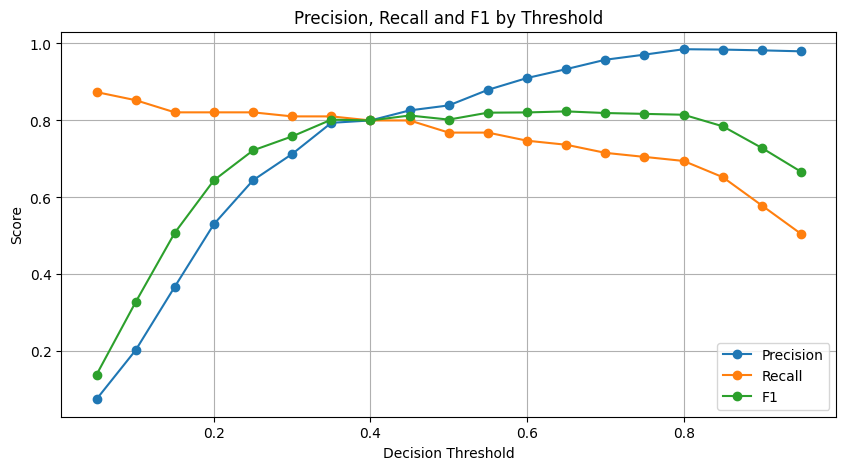

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")

plt.title("Precision, Recall and F1 by Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()

plt.show()

In [32]:
# Best threshold based on F1-score
best_idx = threshold_df["f1"].idxmax()
best_threshold = threshold_df.loc[best_idx, "threshold"]

print(f"Best threshold based on F1-score: {best_threshold:.2f}")

Best threshold based on F1-score: 0.65


In [33]:
# Final prediction using best threshold
y_pred_final = (y_proba >= best_threshold).astype(int)

final_threshold_results = pd.DataFrame([{
    "threshold": best_threshold,
    "precision": precision_score(y_test, y_pred_final, zero_division=0),
    "recall": recall_score(y_test, y_pred_final, zero_division=0),
    "f1": f1_score(y_test, y_pred_final, zero_division=0)
}])

final_threshold_results

,threshold,precision,recall,f1
0,0.65,0.933333,0.736842,0.823529


In [34]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

cm

array([[56646,     5],
       [   25,    70]])

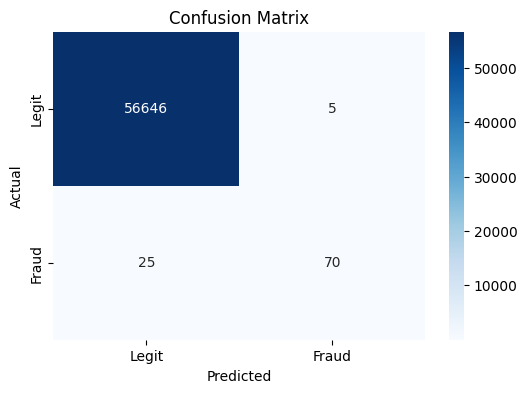

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legit", "Fraud"],
    yticklabels=["Legit", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [36]:
print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Legit", "Fraud"],
    zero_division=0
))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.93      0.74      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



## Classification Report Interpretation

The classification report summarizes the performance of the tuned Random Forest model on the unseen test dataset using the selected decision threshold.

### Legitimate Transactions (Class 0)

- Precision: **1.00**
- Recall: **1.00**
- F1-score: **1.00**

The model correctly identifies almost all legitimate transactions and produces very few false alarms. This indicates excellent performance on the majority class.

### Fraudulent Transactions (Class 1)

- Precision: **0.93**
- Recall: **0.74**
- F1-score: **0.82**

The model correctly detects approximately **74% of all fraudulent transactions** while maintaining a very high precision of **93%**.

This means that when the model flags a transaction as fraudulent, it is correct about **93% of the time**. In practice, only a small proportion of alerts correspond to false positives.

### Precision–Recall Trade-off

The model prioritizes precision over recall:

- High precision (**93%**) means few legitimate transactions are incorrectly flagged.
- Moderate recall (**74%**) means that approximately **26% of fraud cases remain undetected**.

This behavior is often desirable in environments where false alarms are costly and require manual investigation.

### Overall Performance

The fraud class F1-score of **0.82** demonstrates a strong balance between fraud detection capability and false positive reduction.

The macro-average F1-score of **0.91** confirms that the model performs well across both classes despite the severe class imbalance present in the dataset.

### Conclusion

The final Random Forest model achieves strong performance on unseen data. It successfully detects the majority of fraudulent transactions while maintaining a very low false positive rate. With a precision of 93% and a recall of 74%, the model provides a practical balance between operational efficiency and fraud detection effectiveness, making it suitable for deployment in a fraud monitoring environment.

In [37]:
import json
import os

os.makedirs("../models", exist_ok=True)

config = {
    "best_threshold": float(best_threshold)
}

with open("../models/threshold_config.json", "w") as f:
    json.dump(config, f, indent=4)